# Map Converter
This is a Jupyter Notebook to Convert a `.png` or `.pgm` + `.yaml` of a map into a `.csv` that can be fed into the TUMFTM functions.

High Level Steps:
1. Get the Euclidean Distance Transform of the map
2. Apply skeletonization to the map to extract centerlines
3. Run DFS to extract the centerline xy coordinates in order
4. Apply the transformations to go from pixel to meter coordinate frame


Map Conditions:
- Map edges should be well defined, inside should be white, walls are black and outside is grey

In [1]:
import numpy as np
from skimage.morphology import skeletonize
import matplotlib.pyplot as plt
import yaml
import scipy
from scipy.ndimage import distance_transform_edt as edt
from PIL import Image
import os

In [2]:
MAP_NAME = "mexico_map"

TRACK_WIDTH_MARGIN = 0.0 # Extra Safety margin, in meters

Image shape: (2000, 2000), dtype: float64, value range: [0.0, 255.0]


Text(0.5, 1.0, 'mexico_map — raw map')

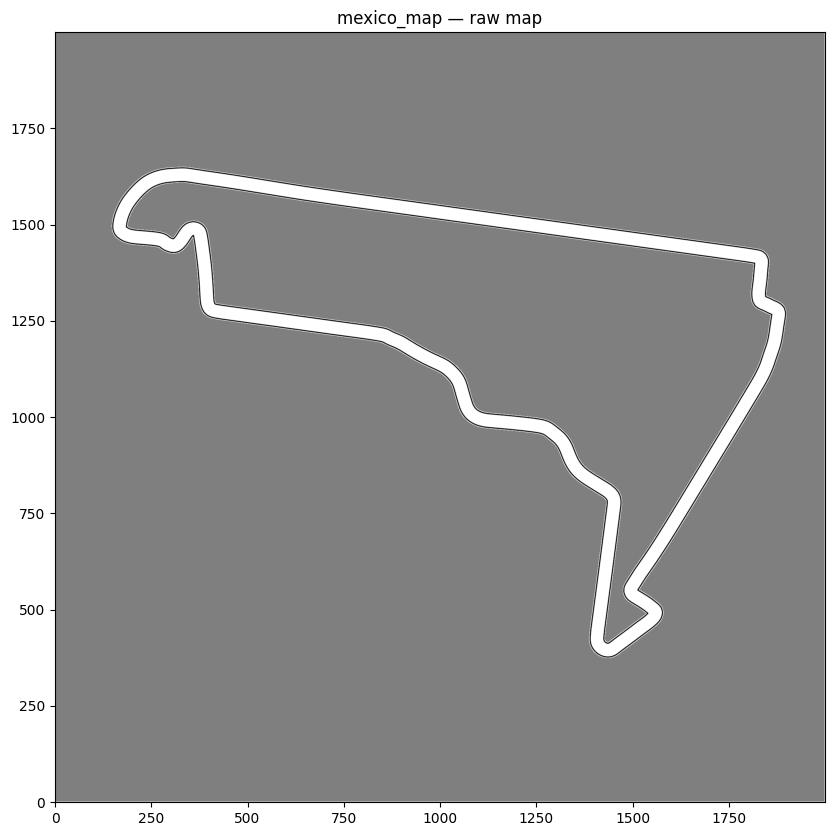

In [3]:
# # Modified from https://github.com/CL2-UWaterloo/Head-to-Head-Autonomous-Racing/blob/main/gym/f110_gym/envs/laser_models.py
# # load map image

# if os.path.exists(f"maps/{MAP_NAME}.png"):
#     map_img_path = f"maps/{MAP_NAME}.png"
# elif os.path.exists(f"maps/{MAP_NAME}.pgm"):
#     map_img_path = f"maps/{MAP_NAME}.pgm"
# else:
#     raise Exception("Map not found!")

# map_yaml_path = f"maps/{MAP_NAME}.yaml"
# raw_map_img = np.array(Image.open(map_img_path).transpose(Image.FLIP_TOP_BOTTOM))
# raw_map_img = raw_map_img.astype(np.float64)

# plt.figure(figsize=(10, 10))
# plt.imshow(raw_map_img, cmap='gray', origin='lower')



# Load map image
if os.path.exists(f"maps/{MAP_NAME}.png"):
    map_img_path = f"maps/{MAP_NAME}.png"
elif os.path.exists(f"maps/{MAP_NAME}.pgm"):
    map_img_path = f"maps/{MAP_NAME}.pgm"
else:
    raise Exception("Map not found!")

map_yaml_path = f"maps/{MAP_NAME}.yaml"

# Force convert to grayscale ('L' = 8-bit) to handle any PNG mode (RGBA, P, I, etc.)
pil_img = Image.open(map_img_path).convert('L').transpose(Image.FLIP_TOP_BOTTOM)
raw_map_img = np.array(pil_img).astype(np.float64)

print(f"Image shape: {raw_map_img.shape}, dtype: {raw_map_img.dtype}, value range: [{raw_map_img.min()}, {raw_map_img.max()}]")

plt.figure(figsize=(10, 10))
plt.imshow(raw_map_img / 255.0, cmap='gray', origin='lower')  # normalize to [0,1] for display
plt.title(f"{MAP_NAME} — raw map")


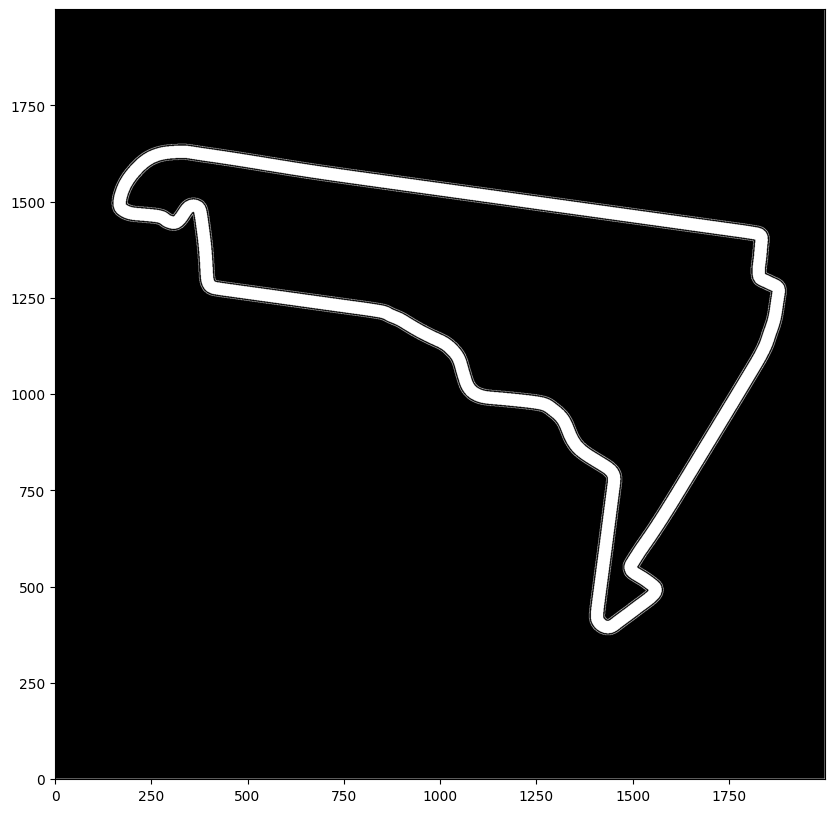

In [4]:
# grayscale -> binary. Converts grey to black
map_img = raw_map_img.copy()
map_img[map_img <= 210.] = 0
map_img[map_img > 210.] = 1

map_height = map_img.shape[0]
# map_width = map_img.shape[1]
map_img
plt.figure(figsize=(10, 10))
plt.imshow(map_img, cmap='gray', origin='lower')

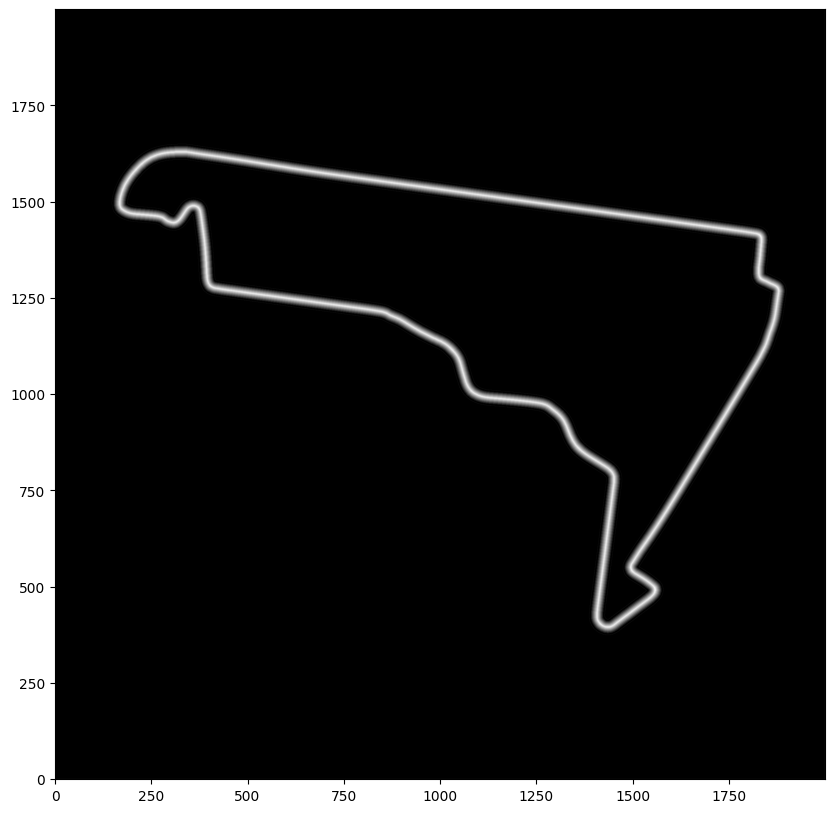

In [5]:
plt.figure(figsize=(10, 10))
# Calculate Euclidean Distance Transform (tells us distance to nearest wall)
dist_transform = scipy.ndimage.distance_transform_edt(map_img)
plt.imshow(dist_transform, cmap='gray', origin='lower')

THRESHOLD=0.17 → 139405 centerline candidate pixels (3.49% of map)


Text(0.5, 1.0, 'Thresholded at 0.17 x max | 139405 pixels')

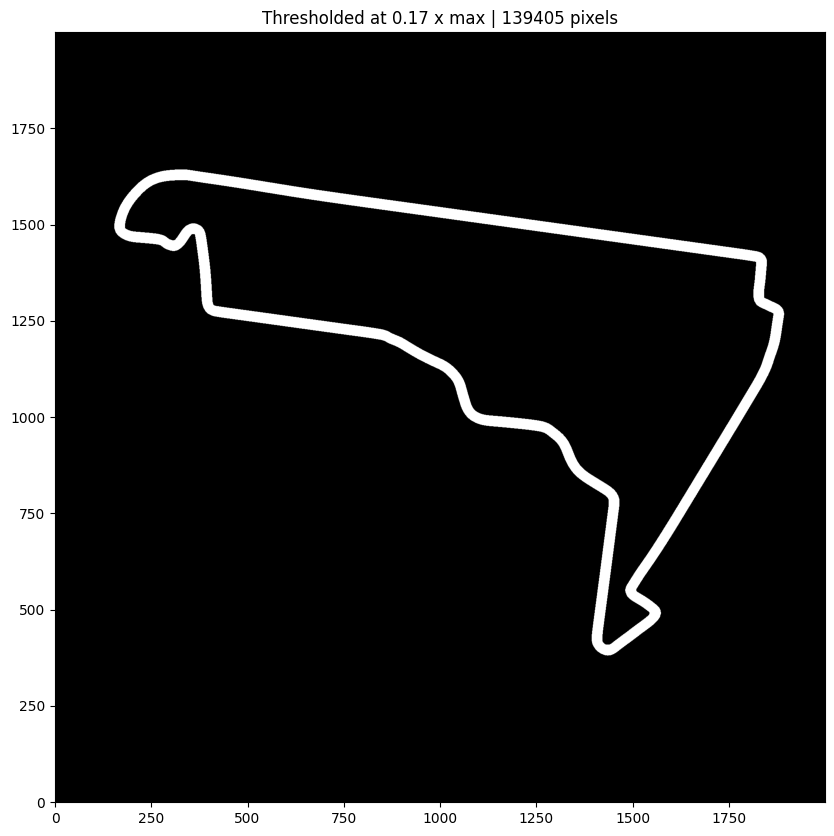

In [6]:
# Threshold the distance transform to create a binary image
# THRESHOLD: fraction of max distance value to keep as centerline candidates
#   Increase (e.g. 0.20–0.35) if you see hairy/branching lines
#   Decrease (e.g. 0.10–0.15) if no centerline appears
THRESHOLD = 0.17

centers = dist_transform > THRESHOLD * dist_transform.max()
n_pixels = int(centers.sum())
map_total = map_img.size

print(f"THRESHOLD={THRESHOLD} → {n_pixels} centerline candidate pixels ({100*n_pixels/map_total:.2f}% of map)")

if n_pixels == 0:
    raise ValueError(f"THRESHOLD={THRESHOLD} is too high — no centerline pixels found. Lower the value.")
if n_pixels > 0.25 * map_total:
    print(f"WARNING: {n_pixels} pixels is {100*n_pixels/map_total:.1f}% of map — THRESHOLD may be too low. Try increasing it.")

plt.figure(figsize=(10, 10))
plt.imshow(centers.astype(np.uint8), origin='lower', cmap='gray')

plt.title(f"Thresholded at {THRESHOLD} x max | {n_pixels} pixels")


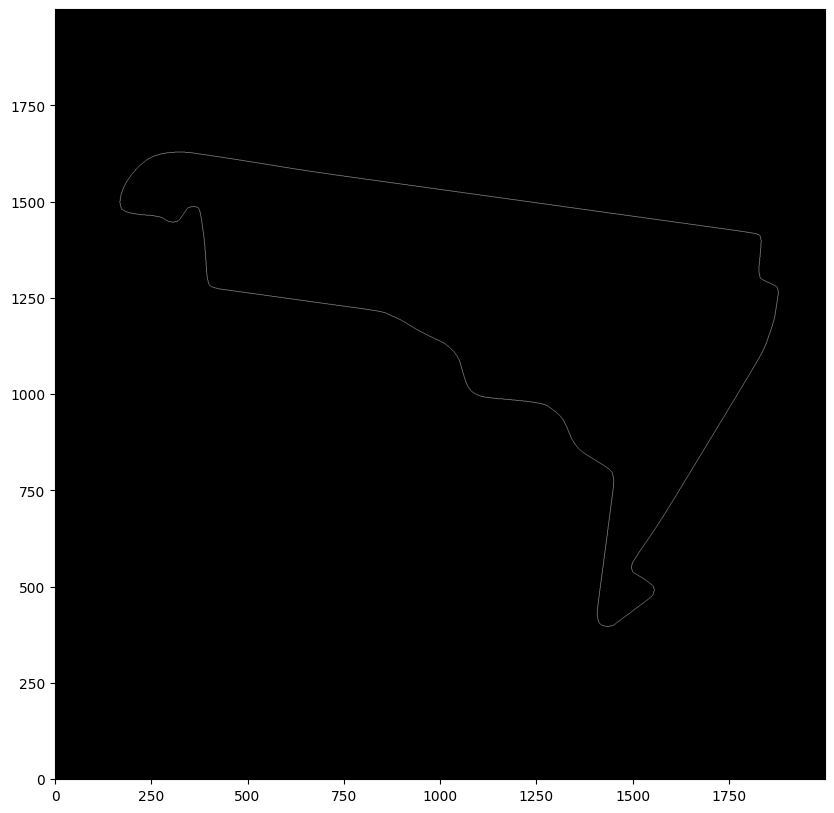

In [7]:
plt.figure(figsize=(10, 10))
centerline = skeletonize(centers)
plt.imshow(centerline.astype(np.uint8), origin='lower', cmap='gray')


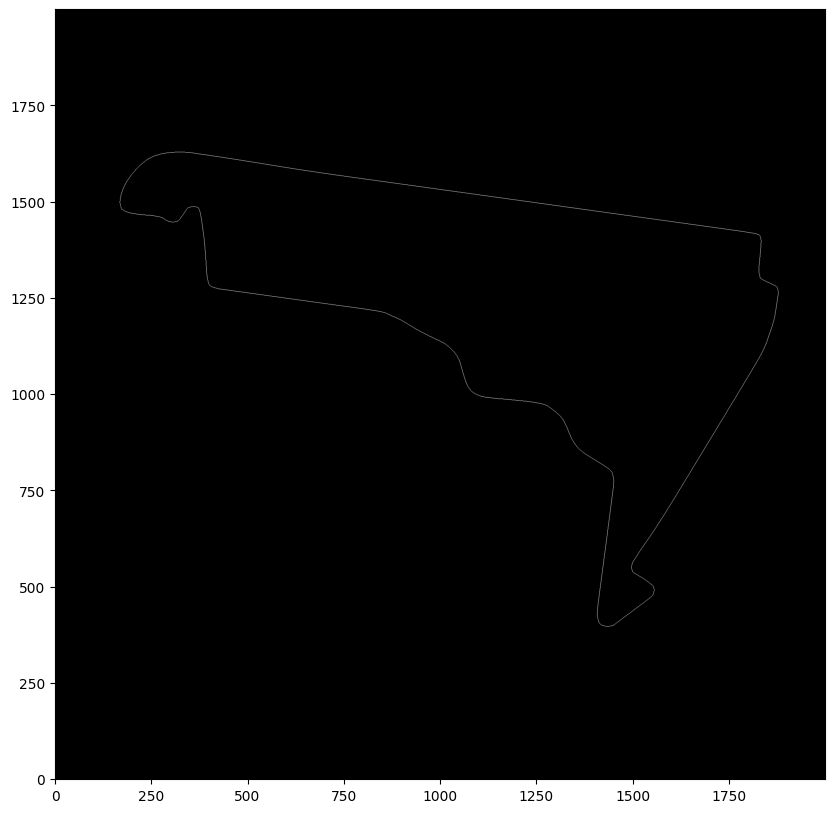

In [8]:
# The centerline has the track width encoded
plt.figure(figsize=(10, 10))
centerline_dist = np.where(centerline, dist_transform, 0)
plt.imshow(centerline_dist, origin='lower', cmap='gray')  # already float, this is fine


In [9]:
# Automatically find a robust starting point on the centerline.
# No hardcoded pixel offsets — works for any map size or resolution.

nonzero_ys, nonzero_xs = np.where(centerline_dist > 0)

if len(nonzero_ys) == 0:
    raise ValueError("No centerline found! Check THRESHOLD value or map image quality.")

h, w = centerline_dist.shape
mid_y = h // 2

# Prefer candidates within 10% of the vertical center (likely on a straight)
center_mask = np.abs(nonzero_ys - mid_y) < (h * 0.1)

if center_mask.sum() > 0:
    cand_ys = nonzero_ys[center_mask]
    cand_xs = nonzero_xs[center_mask]
    # Pick leftmost point for a consistent, repeatable DFS entry
    best = np.argmin(cand_xs)
    left_start_x = int(cand_xs[best])
    left_start_y = int(cand_ys[best])
    print(f"Start point selected from {center_mask.sum()} candidates near vertical center")
else:
    # Fallback: closest pixel to the vertical center of the image
    best = np.argmin(np.abs(nonzero_ys - mid_y))
    left_start_x = int(nonzero_xs[best])
    left_start_y = int(nonzero_ys[best])
    print("WARNING: No centerline near vertical center — using closest fallback point")

# Safety assertions
assert 0 <= left_start_y < h and 0 <= left_start_x < w, \
    f"Start point ({left_start_x}, {left_start_y}) is out of bounds ({w}x{h})!"
assert centerline_dist[left_start_y][left_start_x] > 0, \
    "Start point is not on the centerline — something went wrong."

print(f"Starting position: x={left_start_x}, y={left_start_y} | Map shape: h={h}, w={w}")


Start point selected from 1053 candidates near vertical center
Starting position: x=882, y=1199 | Map shape: h=2000, w=2000


In [10]:
# Start point confirmed — ready for centerline extraction
starting_point = (left_start_x, left_start_y)
print(f"Starting DFS from: {starting_point}")


Starting DFS from: (882, 1199)


In [11]:
# Extract ordered centerline points using iterative DFS.
# Replaces recursive DFS — no recursion limit, bounds-checked, safe on any map size.
from collections import deque

NON_EDGE = 0.0
# 8-directional traversal (order controls which branch is followed first)
DIRECTIONS = [(0, -1), (-1, 0), (0, 1), (1, 0), (-1, 1), (-1, -1), (1, 1), (1, -1)]

h, w = centerline_dist.shape

def extract_centerline_iterative(start_x, start_y):
    """
    Iterative depth-first search to extract ordered centerline points.
    - No Python recursion limit issues (safe on F1 tracks with 10k+ pixels)
    - Full bounds checking before every array access
    - Marks visited on push to avoid duplicate processing
    """
    visited = set()
    points = []
    widths = []

    stack = deque([(start_x, start_y)])
    visited.add((start_x, start_y))

    while stack:
        x, y = stack.pop()  # pop from right = DFS order
        points.append(np.array([x, y]))
        widths.append(np.array([centerline_dist[y][x], centerline_dist[y][x]]))

        for dx, dy in DIRECTIONS:
            nx, ny = x + dx, y + dy
            # Strict bounds check BEFORE any array access
            if 0 <= nx < w and 0 <= ny < h and (nx, ny) not in visited:
                if centerline_dist[ny][nx] != NON_EDGE:
                    visited.add((nx, ny))
                    stack.append((nx, ny))

    return points, widths

centerline_points, track_widths = extract_centerline_iterative(left_start_x, left_start_y)
print(f"Extracted {len(centerline_points)} centerline points")

if len(centerline_points) < 50:
    print("WARNING: Very few centerline points extracted. Check THRESHOLD or map image quality.")


Extracted 4770 centerline points


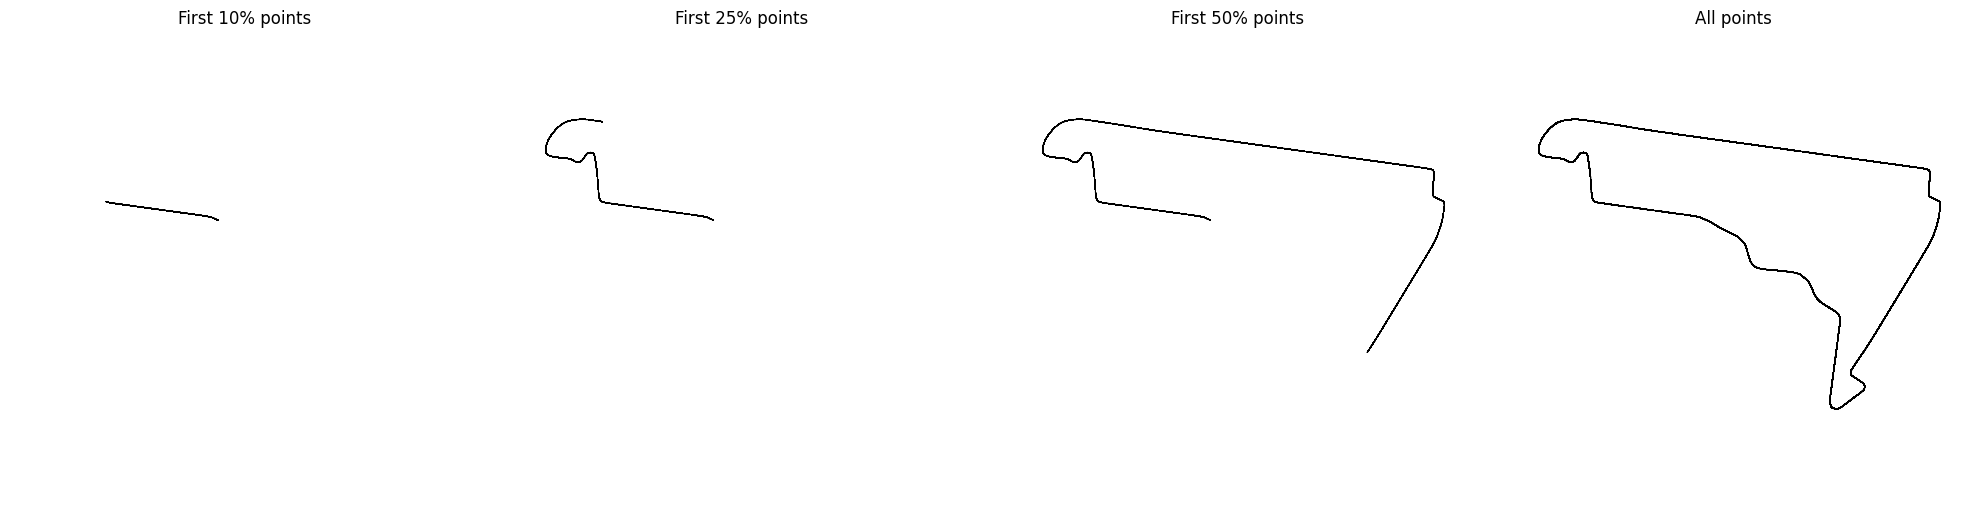

In [12]:
fig, (ax1,ax2,ax3, ax4) = plt.subplots(1, 4, figsize=(20,5))
ax1.axis('off')
ax2.axis('off')
ax3.axis('off')
ax4.axis('off')

centerline_img = np.zeros(map_img.shape)
for x,y in centerline_points[:len(centerline_points)//10]:
	centerline_img[y][x] = 255
ax1.imshow(centerline_img, cmap='Greys', vmax=1, origin='lower')
ax1.set_title("First 10% points")

centerline_img = np.zeros(map_img.shape)
for x,y in centerline_points[:len(centerline_points)//4]:
	centerline_img[y][x] = 255
ax2.imshow(centerline_img, cmap='Greys', vmax=1, origin='lower')
ax2.set_title("First 25% points")

centerline_img = np.zeros(map_img.shape)
for x,y in centerline_points[:int(len(centerline_points)/1.4)]:
	centerline_img[y][x] = 255
ax3.imshow(centerline_img, cmap='Greys', vmax=1, origin='lower')
ax3.set_title("First 50% points")

centerline_img = np.zeros(map_img.shape)
for x,y in centerline_points:
	centerline_img[y][x] = 1000
ax4.imshow(centerline_img, cmap='Greys', vmax=1, origin='lower')
ax4.set_title("All points")
fig.tight_layout()

# Conversion
Convert into Pandas, and go from pixels to meters, and then shift by the origin.

In [13]:
track_widths

[array([16.1245155, 16.1245155]),
 array([15.8113883, 15.8113883]),
 array([16.15549442, 16.15549442]),
 array([15.8113883, 15.8113883]),
 array([16.1245155, 16.1245155]),
 array([16.1245155, 16.1245155]),
 array([16.1245155, 16.1245155]),
 array([16.15549442, 16.15549442]),
 array([15.8113883, 15.8113883]),
 array([16.15549442, 16.15549442]),
 array([16.1245155, 16.1245155]),
 array([16.1245155, 16.1245155]),
 array([15.65247584, 15.65247584]),
 array([16.1245155, 16.1245155]),
 array([16.1245155, 16.1245155]),
 array([16.1245155, 16.1245155]),
 array([15.8113883, 15.8113883]),
 array([16.1245155, 16.1245155]),
 array([15.65247584, 15.65247584]),
 array([16.1245155, 16.1245155]),
 array([15.65247584, 15.65247584]),
 array([15.23154621, 15.23154621]),
 array([15.65247584, 15.65247584]),
 array([16.15549442, 16.15549442]),
 array([15.8113883, 15.8113883]),
 array([15.5241747, 15.5241747]),
 array([16.15549442, 16.15549442]),
 array([15.8113883, 15.8113883]),
 array([15.5241747, 15.52417

In [14]:
track_widths_np = np.array(track_widths)
waypoints = np.array(centerline_points)
print(f"Track widths shape: {track_widths_np.shape}, waypoints shape: {waypoints.shape}")

Track widths shape: (4770, 2), waypoints shape: (4770, 2)


In [15]:
# Merge track with waypoints
data = np.concatenate((waypoints, track_widths_np), axis=1)
data.shape

(4770, 4)

In [16]:
# Load map YAML for resolution and origin
with open(map_yaml_path, 'r') as yaml_stream:
    try:
        map_metadata = yaml.safe_load(yaml_stream)
        map_resolution = map_metadata['resolution']
        origin = map_metadata['origin']
    except yaml.YAMLError as ex:
        raise RuntimeError(f"Failed to parse map YAML: {ex}")

orig_x = origin[0]
orig_y = origin[1]
orig_s = np.sin(origin[2])
orig_c = np.cos(origin[2])

# IMPORTANT: use .copy() to avoid mutating 'data' on re-runs
transformed_data = data.copy().astype(np.float64)

# Convert pixel coordinates → meters, then shift by map origin
transformed_data[:, :2] *= map_resolution
transformed_data[:, :2] += np.array([orig_x, orig_y])

# Convert track widths from pixels → meters, then apply safety margin
transformed_data[:, 2:] *= map_resolution
transformed_data[:, 2:] -= TRACK_WIDTH_MARGIN

# Clamp track widths to a minimum of 0 (safety: never negative width)
transformed_data[:, 2:] = np.clip(transformed_data[:, 2:], 0.01, None)

print(f"Map resolution : {map_resolution} m/px")
print(f"Map origin     : ({orig_x:.3f}, {orig_y:.3f})")
print(f"Track width    : min={transformed_data[:, 2].min():.2f}m, max={transformed_data[:, 2].max():.2f}m")
print(f"Waypoints      : {len(transformed_data)}")


Map resolution : 0.06991 m/px
Map origin     : (-47.264, -110.248)
Track width    : min=0.98m, max=1.16m
Waypoints      : 4770


In [17]:
# Uncomment this if you get the following error: raise IOError("At least two spline normals are crossed, check input or increase smoothing factor!")
transformed_data = transformed_data[::8]

In [18]:
with open(f"inputs/tracks/{MAP_NAME}.csv", 'wb') as fh:
    np.savetxt(fh, transformed_data, fmt='%0.4f', delimiter=',', header='x_m,y_m,w_tr_right_m,w_tr_left_m')

Next up, check out `sanity_check.ipynb` to make sure that the centerline generated lines up with the map.